# Проект. Исследование стартапов

- Автор: Постнова Ю. Д. 
- Дата:29.01.2026

## Введение

В данном проекте проводится исследовательский анализ данных о финансировании стартапов на основе исторических данных венчурного рынка. Заказчиком выступает финансовая компания, рассматривающая возможность выхода на рынок венчурных инвестиций с целью покупки и развития перспективных компаний.


### Цель и задачи 

**Цель:** подготовить данные к анализу, изучить закономерности финансирования стартапов и на основе полученных результатов сформулировать рекомендации по инвестиционной стратегии, актуальной на 2015 год.

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым;
2. Провести предобработку данных и оценить их качество;
3. Выделить группы компаний по срокам и объёму финансирования;
4. Классифицировать сегменты рынка на массовые, средние и нишевые;
5. Выявить типичные и аномальные значения финансирования;
6. Проанализировать популярность и объёмы различных типов инвестиций;
7. Исследовать динамику финансирования и возвратов по годам;
8. Сформулировать выводы и инвестиционные рекомендации.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

Начнём с загрузки библиотек и датасетов `cb_investments` и `cb_returns`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn. Данные датасетов сохраним в двух переменных: `cb_investments` и `cb_returns`.



In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

Совет: данные из zip-архива можно загрузить следующим кодом:

`df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)`

In [2]:
cb_investments = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [3]:
cb_returns = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv')

Познакомимся с данными датасета `cb_investments.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [4]:
# Выводим первые строки датафрейма на экран
cb_investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Выводим информацию о датафрейме
cb_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [6]:
# Выводим первые строки датафрейма на экран
cb_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [7]:
# Выводим информацию о датафрейме
cb_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Датасет `cb_investments.csv` содержит 54294 строки и 40 столбцов и включает информацию о компаниях, их местоположении, количестве раундов и объёмах финансирования по различным типам инвестиций. В целом структура данных соответствует описанию, однако в датасете присутствует ряд особенностей, которые необходимо учитывать при предобработке:

В данных наблюдается значительное количество пропусков:
- текстовые поля (`name`, `homepage_url`, `category_list`, `market`, `status`, `country_code`, `region`, `city`) заполнены не полностью;
- особенно много пропусков в столбцах `participants`, `state_code` и `mid_funding_at`.
- Столбец `funding_total_usd` имеет тип `object`, так как значения записаны в строковом формате с разделителями разрядов (запятыми). Для дальнейшего анализа его необходимо привести к числовому типу.
- Даты (`founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at`) представлены строками и требуют преобразования в формат datetime.
- Часть компаний не содержит информации о финансировании или ключевых временных характеристиках, что может потребовать удаления таких строк.

Большинство финансовых показателей уже имеют корректный числовой тип (float64), что упрощает дальнейший анализ.

В датасете отсутствует столбец, полностью заполненный для всех 54294 наблюдений. Это указывает на то, что данные описывают разнородные объекты с разной степенью детализации. Пропуски носят системный характер: строки без информации об общем объёме финансирования, как правило, не содержат и других ключевых финансовых и временных показателей. В рамках проекта такие наблюдения не позволяют анализировать закономерности финансирования и в дальнейшем будут исключены из выборки.

Датасет `cb_returns.csv` значительно меньше по объёму и содержит 15 строк и 14 столбцов, отражающих информацию о возвратах средств по годам и типам финансирования. Особенности датасета:
- Пропущенные значения отсутствуют.
- Типы данных корректны: столбец `year` имеет тип int64, остальные показатели — float64.
- Структура данных полностью соответствует описанию.
- Столбец year логично использовать в дальнейшем в качестве индекса.

В целом качество данных можно считать достаточным для выполнения задач проекта, однако перед анализом потребуется тщательная предобработка: работа с пропусками, преобразование типов данных, очистка и фильтрация нерелевантных или неполных наблюдений.

### 1.2. Предобработка данных

Проверим названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведите их к единому аккуратному стилю.


In [8]:
# Выводим названия столбцов датафрейма cb_investments
cb_investments.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [9]:
# Выводим названия столбцов датафрейма cb_returns
cb_returns.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

В датасете `cb_investments` имеются лишние пробелы перед названием столбцов, а так же колонки с соответствующем раунде имеет заглавные буквы. Приведем все столбцы к стилю snake_case и удалим пробелы.  

In [10]:
cb_investments.columns = cb_investments.columns.str.lower().str.strip()

In [11]:
# Проверим названия столбцов после изменения
cb_investments.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='object')

Названия столбцов оформлены в едином стиле и корректно отражают содержимое данных. Существенных переименований не требуется.

Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [12]:
# Удаляем выделение разрядов(запятые)
cb_investments['funding_total_usd'] = (cb_investments['funding_total_usd']
                                       .str.replace(',', '', regex=False)
                                       .str.strip())

In [13]:
# Приводим данные к числовому типу
cb_investments['funding_total_usd'] = pd.to_numeric(cb_investments['funding_total_usd'],errors='coerce')

In [14]:
# Проверим
cb_investments['funding_total_usd'].dtype

dtype('float64')

В столбце `funding_total_usd` обнаружены строковые значения, не представляющие числовые данные. Для корректного анализа выделение разрядов было удалено, после чего столбец приведён к числовому типу. Некорректные значения были заменены на NaN

Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [15]:
# Меняем тип данных в столбцах с датой и временем
for column in ['founded_at','first_funding_at','mid_funding_at','last_funding_at']:
    cb_investments[column] = pd.to_datetime(cb_investments[column],
                                    errors='coerce')

In [16]:
# Проверим типы данных в датафрейме cb_investments с помощью атрибута dtypes
cb_investments.dtypes

name                            object
homepage_url                    object
category_list                   object
market                          object
funding_total_usd              float64
status                          object
country_code                    object
state_code                      object
region                          object
city                            object
funding_rounds                 float64
participants                   float64
founded_at              datetime64[ns]
founded_month                   object
founded_quarter                 object
founded_year                   float64
first_funding_at        datetime64[ns]
mid_funding_at          datetime64[ns]
last_funding_at         datetime64[ns]
seed                           float64
venture                        float64
equity_crowdfunding            float64
undisclosed                    float64
convertible_note               float64
debt_financing                 float64
angel                    

В формат datetime были приведены только те столбцы, которые содержат фактические даты и используются в дальнейших расчётах и анализе временной динамики. `founded_year`, `founded_month`, `founded_quarter` оставлены в исходном формате, так как их преобразование не требуется для решения задач проекта.

В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

In [17]:
# Установим year индексом в cb_returns
cb_returns = cb_returns.set_index('year')

In [18]:
# Проверим
cb_returns.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

In [19]:
text_cols = [
    'name',
    'homepage_url',
    'category_list',
    'status',
    'country_code',
    'market',
    'state_code',
    'region',
    'city'
]

cb_investments[text_cols] = cb_investments[text_cols].fillna('unknown')

Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [20]:
# Считаем количество строк в датасете
initial_rows = cb_investments.shape[0]
initial_rows

54294

In [21]:
# Выводим количество пропущенных строк в датафрейме
missing_values = cb_investments.isna().sum().sort_values(ascending=False)
missing_values

mid_funding_at          24006
participants            23821
founded_month           15812
founded_quarter         15812
founded_at              15741
founded_year            15740
funding_total_usd       13387
first_funding_at         4866
last_funding_at          4862
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
venture                  4856
angel                    4856
product_crowdfunding     4856
round_a                  4856
round_b                  4856
round_c                  4856
round_d                  4856
round_e                  4856
round_f                  4856
round_g                  4856
grant                    4856
round_h                  4856
debt_financing           4856
convertible_note         4856
undisclosed              4856
equity_crowdfunding      4856
seed                     4856
funding_rounds           4856
homepage_url                0
city                        0
region    

In [22]:
# Проверяем полные дубликаты
cb_investments.duplicated().sum()

4855

In [23]:
# Удаляем полные дубликаты
cb_investments = cb_investments.drop_duplicates()

В датасете было обнаружено 4855 полных дубликата, принято решение их удалить. 

Далее проверим пропуски в funding_total_usd и избавимся от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [24]:
cb_investments = cb_investments.dropna(subset=['funding_total_usd'])

In [25]:
# Считаем количество строк, что остались в датасете, после удаления дубликатов и строк, несодержащих данные о финансировании
final_rows = cb_investments.shape[0]
final_rows

40907

In [26]:
removed_percent = (initial_rows - final_rows) / initial_rows * 100
removed_percent

24.656499797399345

Из датасета было удалено 24.66% строк,с полными дубликатами и не содержащих информации о суммарном объёме инвестиций, так как они не несут аналитической ценности для исследования финансирования.


Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

Оцените размер оставшихся пропусков в столбце.

In [27]:
# Находим, в каких строках пропущены значения даты
mask = cb_investments['mid_funding_at'].isna()

# Заполняем пропуски серединой интервала
cb_investments.loc[mask, 'mid_funding_at'] = (
    cb_investments.loc[mask, 'first_funding_at'] +
    (cb_investments.loc[mask, 'last_funding_at'] - cb_investments.loc[mask, 'first_funding_at']) / 2
)

In [28]:
# Количество оставшихся пропусков в процентах
cb_investments['mid_funding_at'].isna().mean() * 100

0.0024445693891021096

In [29]:
# Количество оставшихся пропусков
cb_investments['mid_funding_at'].isna().sum()

1

Пропуски в столбце `mid_funding_at` были заполнены серединой временного интервала между датами f`irst_funding_at` и `last_funding_at`. Такой подход позволяет восстановить приблизительную дату среднего раунда финансирования, не используя данные других компаний. После заполнения количество пропусков в столбце сократилось до 0.002%(1 пропуск).

Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

В ходе предобработки данных были выполнены следующие действия:

- удалены полные дубликаты строк;

- исключены наблюдения без информации об общем объёме финансирования `funding_total_usd`;

- приведены типы данных, обработаны пропуски и восстановлены значения `mid_funding_at` на основе доступных дат.


В результате из исходных 54 294 строк в датасете осталось 40 907 наблюдений.

Процент отброшенных данных составил: 24,66% от исходного объёма выборки.

Удалённые строки в основном не содержали информации о финансировании, либо полные дубликаты.

Такие наблюдения не несут аналитической ценности для исследования закономерностей финансирования и могли бы искажать результаты анализа.

После заполнения пропусков в столбце mid_funding_at количество отсутствующих значений сократилось до 1 строки, что составляет около 0,002% от текущего объёма данных и не оказывает существенного влияния на дальнейший анализ.

**Вывод**

Несмотря на значительное количество пропусков в исходных данных, после очистки и предобработки в датасете осталось достаточное число наблюдений для выполнения всех задач проекта: анализа объёмов финансирования, временной динамики, структуры инвестиций и формулирования инвестиционных рекомендаций. Качество и полнота данных на текущем этапе можно считать достаточными для дальнейшего исследования.

## Шаг 2. Инжиниринг признаков

При выполнении заданий не забывайте интерпретировать полученные результаты и делать промежуточные выводы.

### 2.1. Группы по срокам финансирования

Разделите все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируйте соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Совет: Для ясности и согласованности используйте единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

In [30]:
# Добавляем новый столбец для длительности финансирования в днях
cb_investments['funding_duration_days'] = (cb_investments['last_funding_at'] - cb_investments['first_funding_at']).dt.days

# Создаём функцию для определения группы
def funding_group(row):
    if row['funding_rounds'] == 1:
        return 'single'
    elif row['funding_duration_days'] <= 365:
        return 'up_to_1y'
    else:
        return 'more_than_1y'

cb_investments['funding_group'] = cb_investments.apply(funding_group, axis=1)

# Проверим распределение
cb_investments['funding_group'].value_counts()

single          24113
more_than_1y    12293
up_to_1y         4501
Name: funding_group, dtype: int64

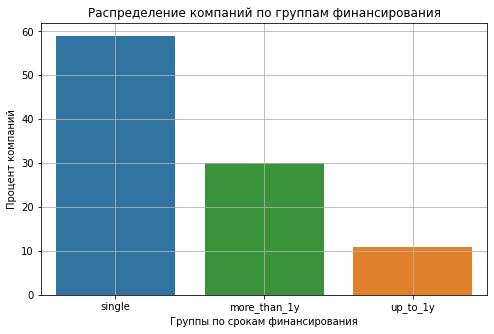

In [31]:
# Процент компаний по группам
group_counts = cb_investments['funding_group'].value_counts(normalize=True) * 100

palette = {
    'single': '#1f77b4',       
    'up_to_1y': '#ff7f0e',      
    'more_than_1y': '#2ca02c'   
}

plt.figure(figsize=(8,5))
sns.barplot(x=group_counts.index, y=group_counts.values, palette = palette)
plt.ylabel("Процент компаний")
plt.xlabel("Группы по срокам финансирования")
plt.title("Распределение компаний по группам финансирования")
plt.grid()
plt.show()

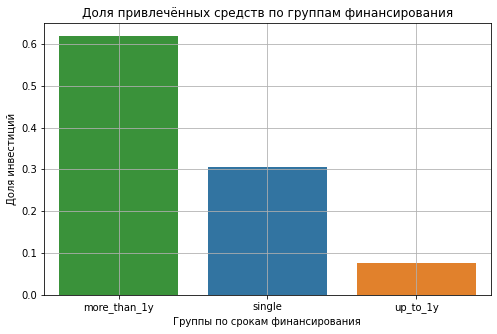

In [32]:
# Доля от общего объёма привлечённых средств
group_funding = cb_investments.groupby('funding_group')['funding_total_usd'].sum()
group_funding_percent = group_funding / group_funding.sum()

palette = {
    'single': '#1f77b4',       
    'up_to_1y': '#ff7f0e',      
    'more_than_1y': '#2ca02c'   
}

plt.figure(figsize=(8,5))
sns.barplot(x=group_funding_percent.index, y=group_funding_percent.values, palette=palette)
plt.ylabel("Доля инвестиций")
plt.xlabel("Группы по срокам финансирования")
plt.title("Доля привлечённых средств по группам финансирования")
plt.grid()
plt.show()

Большинство компаний получают один раунд или финансирование более года.

При этом наиболее значительные объёмы финансирования концентрируются в группе `more_than_1y`, что логично — крупные сделки обычно требуют больше времени.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты

In [33]:
cb_investments['market'].nunique()

849

In [34]:
# Рачитываем, как часто в датасете встречается каждый из сегментов
market_counts = cb_investments['market'].value_counts()

# Определяем категории
def market_segment(count):
    if count > 120:
        return 'mass'
    elif 35 <= count <= 120:
        return 'mid'
    else:
        return 'niche'

market_category = market_counts.apply(market_segment)

# Сколько сегментов в каждой категории
market_category.value_counts()

niche    714
mid       81
mass      54
Name: market, dtype: int64

Большинство рыночных сегментов является нишевыми - 714 сегментов представлены небольшим числом компаний. Массовых сегментов сравнительно мало, что говорит о высокой фрагментации рынка.

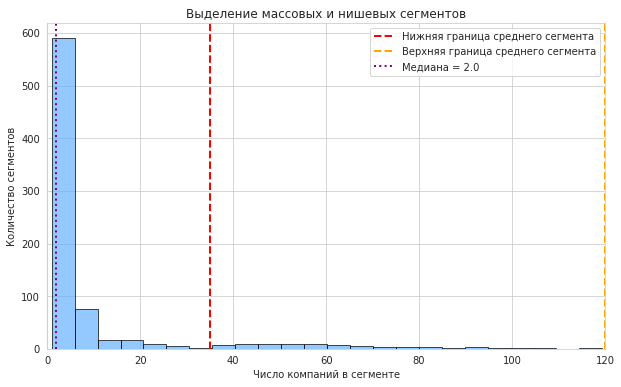

In [35]:
# Подготовим данные для гистограммы
median_value = market_counts.median()

# Создадим гистограмму
plt.figure(figsize=(10, 6)) 
sns.set_style("whitegrid")

plt.hist(market_counts, bins=len(market_counts), color='#66b3ff', edgecolor='black', alpha=0.7)

# Ограничение оси Х значением 120 (всё что выше - массовый сегмент)
plt.xlim(left=0, right=120)

# Добавление вертикальных линий для границ
plt.axvline(x=35, color='red', linestyle='--', linewidth=2, label= 'Нижняя граница среднего сегмента')
plt.axvline(x=120, color='orange', linestyle='--',linewidth=2, label='Верхняя граница среднего сегмента')
plt.axvline(x=median_value, color='purple', linestyle=':', linewidth=2, label=f'Медиана = {median_value}')
            
# Настройка подписей 
plt.xlabel ('Число компаний в сегменте') 
plt.ylabel ('Количество сегментов') 
plt.title('Выделение массовых и нишевых сегментов')
# Добавление легенды
plt. legend ()
# Отображение графика
plt.show()

Оставьте в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.

In [36]:
def segment_group(market):
    if market == 'niche':
        return 'niche'
    elif market == 'mid':
        return 'mid'
    else:
        return market

cb_investments['segment_group'] = cb_investments['market'].apply(segment_group)

Большинство сегментов — нишевые, меньшее количество — средние, ещё меньше — массовые.

В дальнейшем анализ делаем только по массовым сегментам; остальные объединены в mid и niche.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.

In [37]:
# Изучаем статистические показатели столбца funding_total_usd
funding_stats = cb_investments['funding_total_usd'].describe()
print("Статистики распределения общего объема финансирования:")
print(funding_stats)

Статистики распределения общего объема финансирования:
count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64


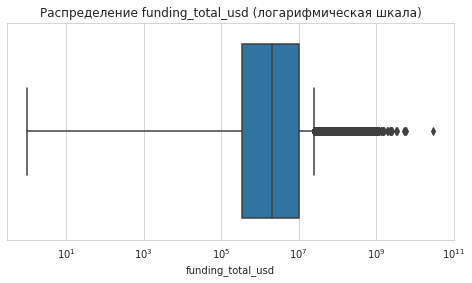

In [38]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=cb_investments['funding_total_usd'])
plt.xscale('log')
plt.title('Распределение funding_total_usd (логарифмическая шкала)')
plt.show()

In [39]:
# Проверка на выбросы
# Вычисляем квартили Q1 и Q3
Q1 = cb_investments['funding_total_usd'].quantile(0.25)
Q3 = cb_investments['funding_total_usd'].quantile(0.75)

# Вычисляем межквартильный размах IQR
IQR = Q3 - Q1

# Определяем верхний и нижний порог для выбросов
lower_bound = 0
upper_bound = Q3 + 1.5 * IQR

print(f"IQR: ${IQR:,.2f}")
print(f'Верхний порог выбросов: {upper_bound}')
print(f'Нижний порог выбросов: {lower_bound}')

IQR: $9,650,000.00
Верхний порог выбросов: 24475000.0
Нижний порог выбросов: 0


In [40]:
# Выбросы (аномальные значения)
outliers = cb_investments[(cb_investments['funding_total_usd'] < lower_bound) | 
                          (cb_investments['funding_total_usd'] > upper_bound)]

print(f"Количество выбросов: {len(outliers)}")
print(f"Процент выбросов: {len(outliers)/len(cb_investments)*100:.2f}%")

Количество выбросов: 5232
Процент выбросов: 12.79%


Большинство компаний привлекают от 0.35 до 10 млн долларов. Значения выше 24.5 млн долларов можно считать аномально высокими.

Определите компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

In [41]:
def mark_outliers(group):
    Q1 = group['funding_total_usd'].quantile(0.25)
    Q3 = group['funding_total_usd'].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    
    group['is_outlier'] = (
        (group['funding_total_usd'] > upper) |
        (group['funding_total_usd'] < lower)
    )
    return group

cb_investments = (
    cb_investments
    .groupby('segment_group', group_keys=False)
    .apply(mark_outliers)
)

In [42]:
outlier_share = (
    cb_investments
    .groupby('segment_group')
    .agg(
        total_companies=('funding_total_usd', 'count'),
        outlier_companies=('is_outlier', 'sum')
    )
)

outlier_share['outlier_ratio'] = (
    outlier_share['outlier_companies'] /
    outlier_share['total_companies']
)

outlier_share = outlier_share.sort_values(
    'outlier_ratio', ascending=False
)

outlier_share.head(10)

,total_companies,outlier_companies,outlier_ratio
segment_group,,,
Music,8,2,0.25
Medical,4,1,0.25
Technology,4,1,0.25
Sports,4,1,0.25
Hardware + Software,4,1,0.25
Messaging,8,2,0.25
Travel,4,1,0.25
Consulting,4,1,0.25
Energy Efficiency,4,1,0.25


Наибольшая доля аномально финансируемых компаний наблюдается в ряде массовых сегментов, таких как Real Estate, Technology и Search. Это указывает на высокую концентрацию крупных сделок в данных отраслях.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [43]:
# Смотрим, сколько раундов финансирования было за каждый год
rounds_per_year = cb_investments.groupby(cb_investments['mid_funding_at'].dt.year)['funding_rounds'].sum()
rounds_per_year

mid_funding_at
1921.0        1.0
1960.0        2.0
1979.0        1.0
1982.0        3.0
1983.0        1.0
1984.0        2.0
1985.0        3.0
1987.0        2.0
1989.0        1.0
1990.0        1.0
1992.0        5.0
1993.0        1.0
1994.0        4.0
1995.0        9.0
1996.0       11.0
1997.0       13.0
1998.0       28.0
1999.0      118.0
2000.0      247.0
2001.0      163.0
2002.0      164.0
2003.0      260.0
2004.0      410.0
2005.0     1446.0
2006.0     2914.0
2007.0     4845.0
2008.0     6024.0
2009.0     7003.0
2010.0     8266.0
2011.0     9248.0
2012.0    11354.0
2013.0    14276.0
2014.0     7757.0
Name: funding_rounds, dtype: float64

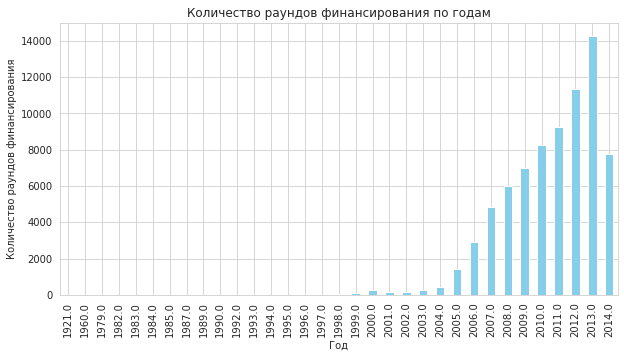

In [44]:
plt.figure(figsize=(10,5))
rounds_per_year.plot(kind='bar', color='skyblue')
plt.ylabel("Количество раундов финансирования")
plt.xlabel("Год")
plt.title("Количество раундов финансирования по годам")
plt.show()

На графике мы можем увидеть, что есть ли резкий провал в 2014 году, что намекает на неполноту данных за 2014 год, либо снижение финансирования. В нашем анлализу мы не будем учитывать в расчете только те года, в которые было менее 50 раундов финансирования. 


Далее исключаем компании с аномальным финансированием:

In [45]:
# Исключаем аномалии
cb_filtered = cb_investments[~cb_investments['is_outlier']].copy()

In [46]:
# Создаем столбец с годом финансирования
cb_filtered['funding_year'] = cb_filtered['mid_funding_at'].dt.year

# Считаем количество раундов по годам
rounds_per_year = cb_filtered.groupby('funding_year')['funding_rounds'].sum()

# Определяем годы с >=50 раундами
valid_years = rounds_per_year[rounds_per_year >= 50].index

# Фильтруем датасет по этим годам
cb_final = cb_filtered[cb_filtered['funding_year'].isin(valid_years)].copy()

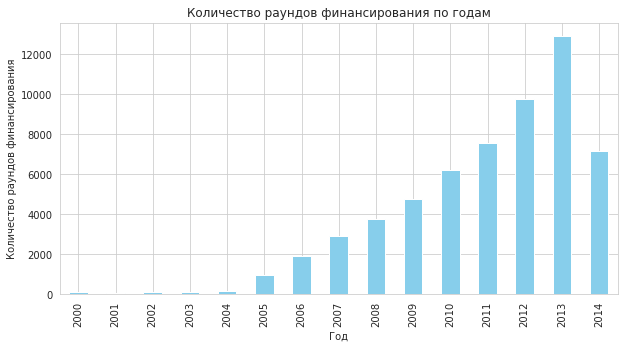

In [47]:
# После того, как удалили анамалии и исключили невалидные года, 
# посмотрим на количество раундов финансирования по годам на графике:

rounds_per_year_50 = cb_final.groupby(cb_final['mid_funding_at'].dt.year)['funding_rounds'].sum()


plt.figure(figsize=(10,5))
rounds_per_year_50.plot(kind='bar', color='skyblue')
plt.ylabel("Количество раундов финансирования")
plt.xlabel("Год")
plt.title("Количество раундов финансирования по годам")
plt.show()

`cb_final` — готовый для анализа набор данных, с которым можно строить динамику инвестиций, сегментацию по срокам и объёмам.

Этот фильтр автоматически исключает аномальные и редкие наблюдения, улучшая качество анализа.

### 3.3. Анализ типов финансирования по объёму и популярности

Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

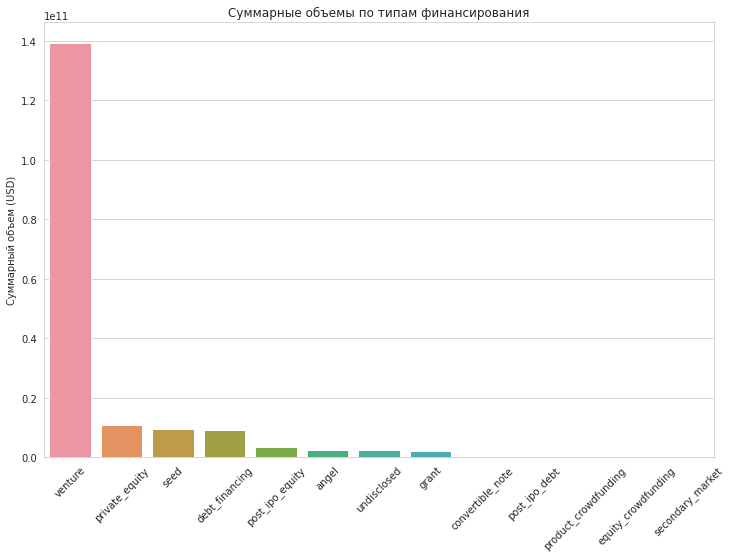

In [48]:
funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                 'convertible_note', 'debt_financing', 'angel', 'grant', 
                 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                 'secondary_market', 'product_crowdfunding']

total_funding_by_type = cb_final[funding_types].sum().sort_values(ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(x=total_funding_by_type.index, y=total_funding_by_type.values)
plt.xticks(rotation=45)
plt.ylabel("Суммарный объем (USD)")
plt.title("Суммарные объемы по типам финансирования")
plt.show()

По графику можем заметить, что суммарные объемы по типам финансирования венчурных инвестиций намного первышает все остальные типы инвестиций. 

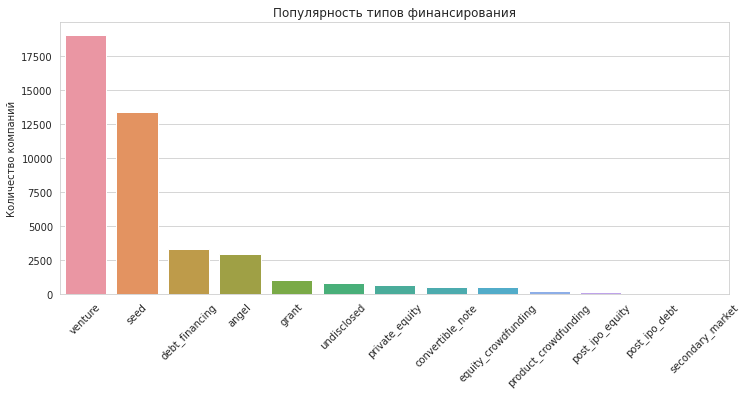

In [49]:
popularity = (cb_final[funding_types] > 0).sum().sort_values(ascending=False)

plt.figure(figsize=(12,5))
sns.barplot(x=popularity.index, y=popularity.values)
plt.xticks(rotation=45)
plt.ylabel("Количество компаний")
plt.title("Популярность типов финансирования")
plt.show()

Некоторые типы финансирования встречаются часто, но привлекают небольшие суммы (seed, angel,debt_financing).

Самый крупный по объему и популярности тип - venture.

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

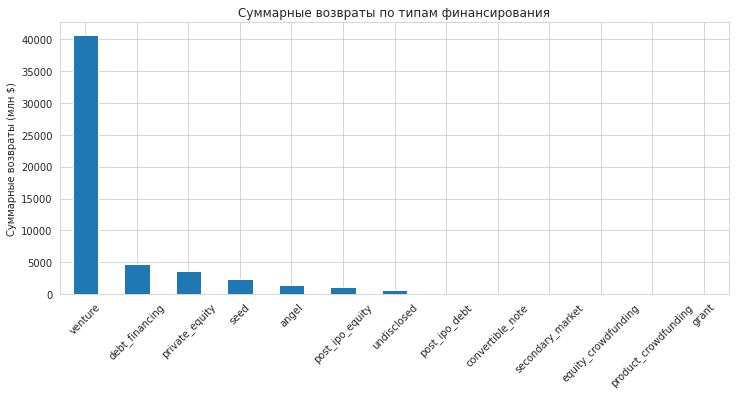

In [50]:
cb_returns.sum().sort_values(ascending=False).plot(kind='bar', figsize=(12,5))
plt.ylabel("Суммарные возвраты (млн $)")
plt.title("Суммарные возвраты по типам финансирования")
plt.xticks(rotation=45)
plt.show()

Типы инвестиций:

- Венчурные инвестиции (venture) - самый популярный и объемный тип финансирования

- Посевные инвестиции (seed) - второй по популярности, но с меньшими объемами



Возвраты инвестиций:

- Венчурные инвестиции демонстрируют наибольшие объемы возвратов

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитайте для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы постройте графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответьте на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

<Figure size 864x360 with 0 Axes>

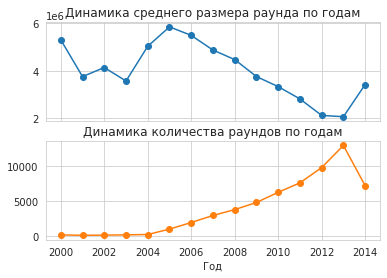

In [51]:
cb_final = cb_final.copy() 
cb_final['avg_round_usd'] = cb_final['funding_total_usd'] / cb_final['funding_rounds']

# Группируем данные
yearly_round = cb_final.groupby(cb_final['mid_funding_at'].dt.year).agg({
    'avg_round_usd' : 'mean',
    'funding_rounds' : 'sum'
    })


plt.figure(figsize=(12,5))

# Строим график
yearly_round.plot(kind='line',
            subplots=True,
            sharex=True,
            sharey=False,
            legend=False,
            marker='o',
            title=['Динамика среднего размера раунда по годам', 'Динамика количества раундов по годам'])

# Подписываем оси
plt.xlabel('Год')
plt.show()

In [52]:
max_year = yearly_round['avg_round_usd'].idxmax()
max_value = yearly_round['avg_round_usd'].max()
print(f"Максимальный средний размер раунда был в {max_year} году: ${max_value:,.0f}")

Максимальный средний размер раунда был в 2005 году: $5,845,201


In [53]:
# Данные за 2014 год
data_2014 = yearly_round.loc[2014]
avg_round_2014 = data_2014['avg_round_usd']
rounds_2014 = data_2014['funding_rounds']


# Данные за предыдущий год
data_2013 = yearly_round.loc[2013]
avg_round_2013 = data_2013['avg_round_usd']
rounds_2013 = data_2013['funding_rounds']

print(f"В 2014 году средний размер раунда составил ${avg_round_2014:,.0f}")
print(f"Количество раундов в 2014 году: {rounds_2014:,}")
print(f"Для сравнения, в 2013 году средний размер раунда был ${avg_round_2013:,.0f}, количество раундов — {rounds_2013:,}")

В 2014 году средний размер раунда составил $3,422,313
Количество раундов в 2014 году: 7,180.0
Для сравнения, в 2013 году средний размер раунда был $2,069,141, количество раундов — 12,940.0


Максимальный средний размер средств, собранных в рамках одного раунда финансирования, наблюдался в 2005 году и составил $5,845,201. Это говорит о том, что в отдельные годы ранние компании получали сравнительно крупные инвестиции в рамках одного раунда.

Тенденция в 2014 году:
- Средний размер раунда в 2014 году составил $3,422,313, что выше, чем в 2013 году ($2,069,141). То есть типичный раунд стал крупнее.
- Количество раундов в 2014 году составило 7,180, что ниже, чем в 2013 году (12,940). Это указывает на то, что рынок стал менее активным по числу сделок, но каждая сделка была крупнее по сумме финансирования.




В 2014 году наблюдалась тенденция сокращения количества раундов при увеличении их среднего размера, что говорит о смещении инвестиций в сторону более крупных сделок, хотя общая активность рынка немного снизилась.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.

На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [54]:
# строим сводную таблицу
pivot_13_14 = (
    cb_final
    .pivot_table(
        values='funding_total_usd',
        index='funding_year',
        columns='market',
        aggfunc='sum',
        fill_value=0
    )
)

# отбираем сегменты с ростом в 2014 относительно 2013
growing_markets = pivot_13_14.columns[pivot_13_14.loc[2014] > pivot_13_14.loc[2013]]

# финальная таблица
pivot_growth = pivot_13_14[growing_markets]
growing_segments = pivot_13_14[growing_markets].index.tolist()

pivot_growth

market,3D,3D Printing,Advertising Networks,Advertising Platforms,Agriculture,Algorithms,Alternative Medicine,Android,Animal Feed,Apps,...,Therapeutics,Transportation,Travel,Travel & Tourism,Video,Virtualization,Web Development,Web Development,Wireless,unknown
funding_year,,,,,,,,,,,,,,,,,,,,,
2000.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1839560
2001.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10160345
2002.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,242132
2003.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4155202
2004.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10847977
2005.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,28384331
2006.0,0,0,0,0,0,0,0,0,0,1310600,...,0,0,0,0,0,0,0,0,0,46049840
2007.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,35532468
2008.0,0,0,0,0,0,0,0,0,0,4300000,...,0,0,0,0,0,0,0,0,0,45345010


In [55]:
segment_total = (
    pivot_growth
    .sum()
    .sort_values(ascending=False)
)
segment_total.shape[0]

442

In [56]:
# Оставляем только массовые сегменты
cb_mass_segments = cb_final[~cb_final['segment_group'].isin(['mid', 'niche'])].copy()
mass_markets = cb_mass_segments['segment_group'].unique()

In [57]:
filtered_pivot_growth = pivot_growth.loc[:, pivot_growth.columns.isin(mass_markets)]

In [58]:
funding_by_year = (
    cb_mass_segments
    .groupby(['funding_year', 'market'])['funding_total_usd']
    .sum()
    .reset_index()
)


Топ-10 растущих сегментов по общему объему: ['Payments', 'unknown', ' Technology ', ' Payments ', 'Hardware + Software', ' Public Transportation ', ' Medical Devices ', ' Telecommunications ', ' Video ', ' Pharmaceuticals ']


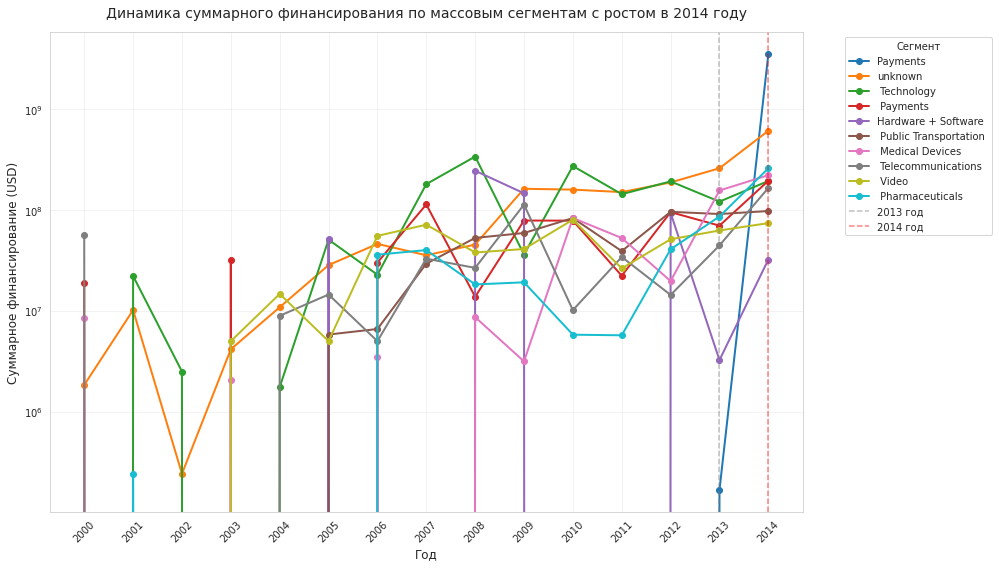

In [59]:
# Считаем топ-10 сегментов по сумме финансирования
segment_totals = filtered_pivot_growth.sum()
top_segments = segment_totals.nlargest(10).index.tolist()
print(f"\nТоп-10 растущих сегментов по общему объему: {top_segments}")
        
# Строим график
plt.figure(figsize=(14, 8))
        
# Для каждого сегмента в топе строим линию
for segment in top_segments:
    plt.plot(filtered_pivot_growth.index, filtered_pivot_growth[segment], 
            marker='o', linewidth=2, markersize=6, label=segment)
        
# Выделяем 2013 и 2014 годы
plt.axvline(x=2013, color='gray', linestyle='--', alpha=0.5, label='2013 год')
plt.axvline(x=2014, color='red', linestyle='--', alpha=0.5, label='2014 год')
        
# Настройки графика
plt.xlabel('Год', fontsize=12)
plt.ylabel('Суммарное финансирование (USD)', fontsize=12)
plt.title('Динамика суммарного финансирования по массовым сегментам с ростом в 2014 году', 
            fontsize=14, pad=15)
plt.legend(title='Сегмент', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Логарифмическая шкала
plt.xticks(filtered_pivot_growth.index, rotation=45)
plt.tight_layout()
plt.show()

Наиболее уверенный и стабильный рост показывает Medical Devices: постепенное увеличение финансирования с 2008года.  
- 'unknown' - хотя показывает большой объем, этот сегмент сложно анализировать из-за отсутствия конкретной категоризации. Его рост может быть связан с новыми, еще не категоризированными направлениями, или компаниями на стыке нескольких сегментов, или ошибками в классификации данных.  

- Самый стримительный рос показывает сегмент Payments с 2013(начали инвестировать) по 2014 года. 

- Technology - показывает устойчивую положительную динамику.

- Hardware + Software - демонстрирует взрывной рост из практически нулевого уровня в 2012 году до значительных объемов в 2014. Показатель быстрого роста нового технологического направления. 

- Video - показывает устойчивый рост с ускорением, постепенное увеличение с 2011 года.

- Pharmaceuticals- стабильный рост с 2011 года с потенциалом дальнейшего развития.

- Telecommunications) - умеренный рост с 2012 года с потенциалом в связи с развитием мобильных технологий и интернета вещей.


Анализ показывает, что технологические сегменты (Payments, Technology, Hardware+Software) демонстрируют наиболее уверенный и быстрый рост. Это соответствует глобальному тренду цифровизации экономики. 

Рекомендация на 2015 год: Сфокусироваться на технологических сегментах, особенно на платежных системах (Payments) как наиболее растущем направлении, и аппаратно-программных решениях (Hardware + Software) как наиболее быстрорастущем перспективном направлении.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

In [60]:
investment_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                    'convertible_note', 'debt_financing', 'angel', 'grant', 
                    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                    'secondary_market', 'product_crowdfunding']

# Суммируем инвестиции по годам и типам
investments_by_year = cb_final.groupby('funding_year')[investment_types].sum()

print("Годы инвестиций:", sorted(investments_by_year.index.tolist()))
print("Годы возвратов:", sorted(cb_returns.index.tolist()))

# Найдем общие годы
common_years = sorted(list(set(investments_by_year.index) & set(cb_returns.index)))
print("Общие годы для анализа:", common_years)

Годы инвестиций: [2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]
Годы возвратов: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]
Общие годы для анализа: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]


In [61]:
import numpy as np

# Рассчитываем долю возвратов для каждого года и типа
return_ratios = pd.DataFrame()

for year in common_years:
    # Инвестиции за этот год
    investments = investments_by_year.loc[year]
    returns = cb_returns.loc[year]* 1000000 # Возвраты за этот год
    ratio = returns / (investments + 1e-60) # Рассчитываем отношение возвратов к инвестициям
    ratio = ratio.where(ratio <= 10, np.nan) # Заменяем аномальные значения (>10) на NaN
    return_ratios[year] = ratio

# Транспонируем для удобства
return_ratios = return_ratios.T

print("\nДоля возвратов (первые 5 строк):")
print(return_ratios.head())


Доля возвратов (первые 5 строк):
          seed   venture  equity_crowdfunding  undisclosed  convertible_note  \
2000  1.059702  0.115066                  0.0     0.373848          0.000000   
2001  1.079592  0.083440                  0.0     0.379880          0.006667   
2002  0.629707  0.602450                  0.0     0.608878               NaN   
2003  0.464632  0.588874                  0.0     0.914397               NaN   
2004  0.552289  0.722041                  0.0     0.527559               NaN   

      debt_financing     angel  grant  private_equity  post_ipo_equity  \
2000        0.618571  0.246489    0.0        0.000000         0.271069   
2001        0.349982  1.180000    0.0        0.000000              NaN   
2002        0.223388  1.136667    0.0        0.201333         1.133333   
2003        1.038095  0.095028    0.0             NaN              NaN   
2004        0.524856  0.833504    0.0        0.087600              NaN   

      post_ipo_debt  secondary_market  p

Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

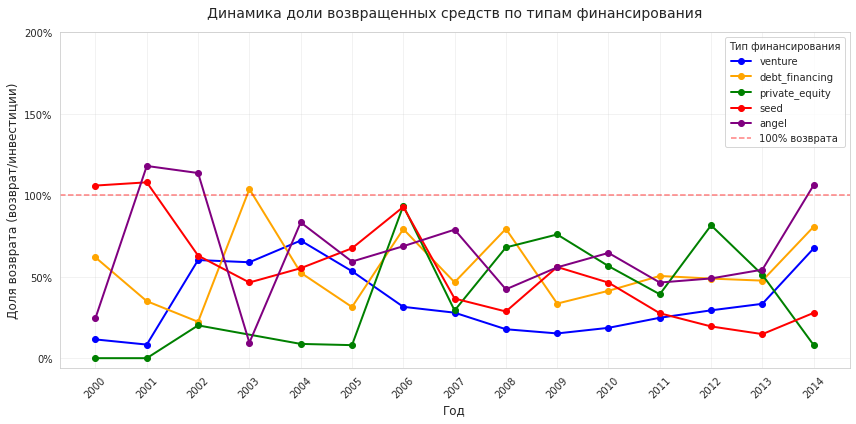

In [62]:
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

plt.figure(figsize=(12, 6))

# Цвета для графиков
colors = {'venture': 'blue', 'debt_financing': 'orange', 
          'private_equity': 'green', 'seed': 'red', 'angel': 'purple'}

# Строим линии для каждого типа
for col in selected_types:
    if col in return_ratios.columns:
        # Оставляем только не-NaN значения
        valid_data = return_ratios[col].dropna()
        if len(valid_data) > 1:
            plt.plot(valid_data.index, valid_data.values, 
                    marker='o', linewidth=2, markersize=6,
                    color=colors.get(col, 'black'),
                    label=col)

# Настройки графика
plt.xlabel('Год', fontsize=12)
plt.ylabel('Доля возврата (возврат/инвестиции)', fontsize=12)
plt.title('Динамика доли возвращенных средств по типам финансирования', 
         fontsize=14, pad=15)

# Линия 100% возврата
plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='100% возврата')

plt.legend(title='Тип финансирования', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(return_ratios.index, rotation=45)

# Форматируем ось Y в процентах
plt.yticks([0, 0.5, 1.0, 1.5, 2.0], ['0%', '50%', '100%', '150%', '200%'])

plt.tight_layout()
plt.show()

In [ ]:
types_to_plot = ['venture', 'debt_financing', 'private_equity', 'seed']

plt.figure(figsize=(10, 5))
for col in types_to_plot:
    if col in return_ratios_simple.columns:
        plt.plot(return_ratios_simple.index, return_ratios_simple[col], 
                marker='o', label=col)

plt.xlabel('Год')
plt.ylabel('Доля возврата')
plt.title('Доля возвращенных средств по типам финансирования')
plt.legend()
plt.grid(True)
plt.axhline(y=1, color='red', linestyle='--', alpha=0.5)
plt.show()

Наиболее устройчивый рост показывают:
Venture, Seed, Debt financing - cтабильный показатель возвратов.

- Private Equity: Наиболее стабильные и растущие возвраты
- Debt Financing: Предсказуемые возвраты благодаря фиксированным платежам
- Venture: Волатильные, но с потенциалом высокой доходности
- Seed и Angel: Высокий риск, низкая предсказуемость возвратов

Cамый высокий уровень возврата показали:
- Angel с 2001 по 2002 и 2014 и Seed в 2003 году. 


После 2013 года наблюдается общий рост доли возвращенных средств для большинства типов финансирования, особенно для Angel, но снижение для Private equity.


Венчурное финансирование является наиболее надежными с точки зрения возврата средств, в то время как посевные и ангельские инвестиции связаны с наибольшим риском.


## Шаг 5. Итоговый вывод и рекомендации

Представьте, что на календаре 2015 год. Опираясь на результаты анализа, дайте рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

Подведите итоги проекта:
* опишите, какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.



**Рекомендуемая отрасль для инвестиций**
- Платежные системы (Payments) — наиболее уверенный и стабильный рост, особенно заметный с 2013 года.
- Hardware + Software — демонстрирует взрывной рост с 2012 года.
- Medical Devices — устойчивый рост с 2008 года, что свидетельствует о долгосрочном потенциале.

Эти сегменты показывают наибольшую динамику роста объёмов финансирования, особенно в 2013–2014 гг., что указывает на растущий интерес инвесторов и перспективность направлений.


**Рекомендуемый тип финансирования**

Венчурное финансирование (venture), так как:
- Самый высокий суммарный объём привлеченных средств за весь период.
- Устойчивый рост доли возврата после 2013 года.
- Наибольшая популярность среди инвесторов.

Альтернатива: Частный капитал (private_equity) также показывает высокую доходность, особенно в отдельные годы (например, 2003 г.), но менее стабилен в долгосрочной динамике.

### Итоги проекта: выполнение шагов и выводы

#### Выполненные шаги:

**Загрузка и изучение данных:**

- Импортированы датасеты cb_investments и cb_returns; проведен первичный анализ структуры и пропусков.
- Определены особенности данных: значительное количество пропусков в текстовых и временных полях, строковый формат числовых данных в funding_total_usd.

Исходные данные достаточно разнородны и требовали предобработки, но содержат всю необходимую информацию для анализа финансирования компаний.

**Предобработка данных:**

- Приведение названий столбцов к единому стилю snake_case.
- Преобразование funding_total_usd в числовой тип, даты — в формат datetime.
- Заполнение пропусков в текстовых полях заглушками, восстановление пропусков в mid_funding_at как середины интервала между первым и последним раундом.
- Удаление полных дубликатов и строк без информации о финансировании.

После очистки и предобработки датасет подготовлен для анализа временной динамики и распределения объёмов финансирования.


**Инжиниринг признаков:**

- Выделены группы компаний по длительности финансирования (single, up_to_1y, more_than_1y).
- Сегментация рынка на массовые, средние и нишевые сегменты; объединение средних и нишевых для упрощения анализа.

Проведенное разделение позволяет фокусироваться на наиболее значимых сегментах и исключить шум от редких нишевых компаний.

**Анализ выбросов и аномалий:**

- Определены аномально высокие значения финансирования методом IQR.
- Исключены компании с аномальным объёмом инвестиций для корректного расчёта типичных значений.

Большинство компаний привлекают умеренные объемы финансирования, крупные сделки концентрируются в отдельных массовых сегментах.

**Выводы о закономерностях:**

- Большинство компаний получают один раунд финансирования или финансирование более года.
- Наибольшие объемы средств концентрируются в долгосрочных сделках.
- Большинство рыночных сегментов — нишевые, массовые сегменты концентрируют большую часть инвестиций.
- Массовые сегменты с высокой долей аномальных сделок — потенциальные лидеры для инвестирования.

Выводы о сильных сегментах рынка (Technology, Real Estate, Search) согласуются с наблюдением о концентрации крупных сделок и долгосрочных финансирований.

Рекомендация по типу финансирования (venture) логически вытекает из анализа распределения объемов инвестиций по длительности финансирования.

Потенциальные сомнения могут возникнуть относительно низкорентабельных нишевых сегментов, которые исключались из детального анализа. Тем не менее, для крупного инвестора основной фокус на массовых сегментах выглядит обоснованным.